In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HANDWRITTEN DIGITS DATASET.zip to HANDWRITTEN DIGITS DATASET.zip


In [ ]:
import zipfile

with zipfile.ZipFile("HANDWRITTEN DIGITS DATASET.zip", 'r') as zip_ref:
    zip_ref.extractall()

print(" Dataset Extracted")

 Dataset Extracted


In [ ]:
import tensorflow as tf  # model build ani train karnyasathi use keli jati ani main library ahe DL chi
from tensorflow.keras import layers, models #layer create  ani model ch full neural network create karnyasathi
import os #dataset folder read krte
import cv2 #image process karnyasathi use krta resize converting
import numpy as np # array  ani number
import matplotlib.pyplot as plt

In [ ]:
data = []
labels = []

base_path = "HANDWRITTEN DIGITS DATASET"


for file_name in os.listdir(base_path):
    if file_name.endswith(('.jpeg', '.png', '.jpg')): #image ch work krta bki khe nhi
        try:

            label = int(file_name.split('_')[0])  #image format nit pahej short mdhi label
        except ValueError:
            print(f"Skipping file with unparsable label: {file_name}")
            continue

        path = os.path.join(base_path, file_name) #filder file name ani file path combine krta

        img = cv2.imread(path)
        if img is None:
            print(f"Warning: Could not read image {path}. Skipping.")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #photo black ani white mdhi taiyar krte
        gray = 255 - gray  #kala pandhra , pandhra kala

        _, gray = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY) #model gigit wartich focus krte

        resized = cv2.resize(gray, (28,28)) #photo recognition sathi standard size ahe he
        normalized = resized / 255.0

        data.append(normalized) #process photo save hoto ani tyach label
        labels.append(label)

data = np.array(data).reshape(-1,28,28,1) # 1 mhnje grayscale channel ahe
labels = np.array(labels) #label array hota eth

print(" Data Loaded:", data.shape) #photo kiti load ahe sangta

 Data Loaded: (100, 28, 28, 1)


In [ ]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(), #2d ch 1d mdhi
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
]) # 32 filter usekele ani size 3 by 3  relu pattern learn karnyasathi use kela   ani pooling size reduce sathi

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', # adam ha algo ahe model la fast learn karnyasathi
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(data, labels, epochs=15)

print(" Training Done")

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.0900 - loss: 2.3149
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3800 - loss: 2.1913
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3700 - loss: 2.0918
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 1.9594
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4800 - loss: 1.8045
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5100 - loss: 1.6605
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.5100 - loss: 1.4998
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6500 - loss: 1.3236
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6500 - loss: 1.1971
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6000 - loss: 1.1256
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6700 - loss: 1.0587
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7400 - loss: 0.8975


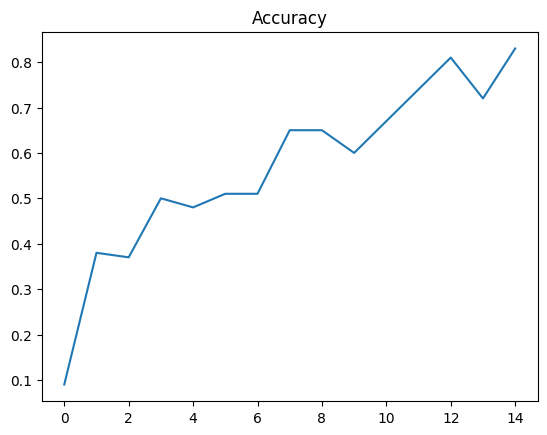

In [ ]:
plt.plot(history.history['accuracy'])
plt.title("Accuracy")
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 0_9.jpeg to 0_9.jpeg


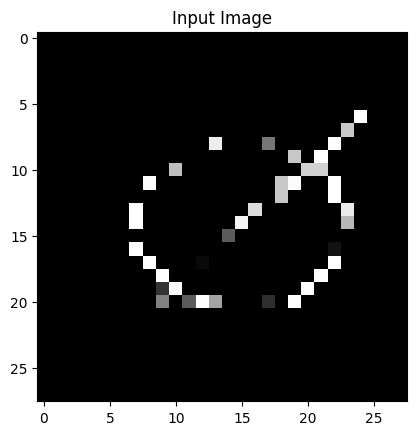

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
 Predicted Digit: 0


In [ ]:
img = cv2.imread(list(uploaded.keys())[0]) #jo photo upload kela ahe to read hoto

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = 255 - gray
_, gray = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY) #noise kdhun karnyasathi threshold

resized = cv2.resize(gray, (28,28))
normalized = resized / 255.0 #oixel value he 0 to 1 mdhi
reshaped = normalized.reshape(1,28,28,1)

plt.imshow(resized, cmap='gray')
plt.title("Input Image")
plt.show()

prediction = model.predict(reshaped) # probabiliti 0 to 9 mdhi photo chi
print(" Predicted Digit:", np.argmax(prediction))